## READNE


In this notebook, we performed the following steps:

1.  **Data Loading:** 'Home Credit Default Risk' competition data was loaded using `kagglehub`.
2.  **Data Wrangling:** The `wrangle` function was applied to clean the data, handle outliers, create new features, convert time-based columns to years, and process income and occupation types.
3.  **Missing Value Handling:** The `full_missing_pipeline` function was used to deal with missing values, which included analyzing missing value percentages, grouping columns with significant missingness, dropping some columns, creating missing value flags, and imputing missing values (with the median for numerical and mode for categorical values).
4.  **Data Splitting:** The data was split into training and testing sets (a separate validation set was later used for decision tree model tuning).
5.  **Model Training and Evaluation:**

    *   **Logistic Regression:** A Pipeline including OneHotEncoder, StandardScaler, and a Logistic Regression model was built.
    *   **Random Forest:** A Pipeline including OneHotEncoder and a Random Forest model was built.
    *   **CatBoost:** Data was prepared for the CatBoost model, which handles categorical features directly.

During the experimentation process, I tried different data processing methods and their impact on model performance, including:

*   **Experiment 1 (My prepare - depth 6):** With my initial settings, including `wrangle` and `full_missing_pipeline` functions, CatBoost achieved **0.7631 AUC**.
*   **Experiment 2 (My prepare):** This experiment was a repeat of Experiment 1 with the same settings, yielding a CatBoost AUC of **0.7627**.
*   **Experiment 3 (0.05 importance, 50%):** After adjusting missing value handling criteria (0.05 importance and 50% missing values), CatBoost performance decreased to **0.7585 AUC**.
*   **Experiment 4 (only wrangle):** Using only the `wrangle` function without advanced missing value handling from `full_missing_pipeline`, CatBoost yielded **0.7627 AUC**.
*   **Experiment 5 (0.005 importance, 60% - NO MISS FLAGS):** With other missing value handling criteria (0.005 importance and 60% missing values, without adding missing flag columns), CatBoost yielded **0.7618 AUC**.

**Final Result:**

After a series of experiments and adjustments to the data processing pipeline, I settled on the **CatBoost** model as the best-performing one in this case. The best result was achieved using my initial setup ('My prepare') for CatBoost, where the **Valid ROC-AUC** reached **0.7627**.

# Settings

In [55]:
!pip install catboost

In [56]:
from typing import TextIO
import kagglehub
kagglehub.login()
#

Kaggle credentials set.
Kaggle credentials successfully validated.


In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [58]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.rcParams.update({
    'figure.figsize': (4,3),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [59]:
path = kagglehub.competition_download('home-credit-default-risk')

os.listdir(path)

['credit_card_balance.csv',
 'sample_submission.csv',
 'application_test.csv',
 'bureau.csv',
 'previous_application.csv',
 'application_train.csv',
 'HomeCredit_columns_description.csv',
 'POS_CASH_balance.csv',
 'bureau_balance.csv',
 'installments_payments.csv']

In [60]:
train_path = path + "/application_train.csv"
df_BASE = pd.read_csv(train_path)

In [89]:
# downlad df_BASE
df_BASE.to_csv("df_BASE.csv", index=False)

# downlad df
df.to_csv("df.csv", index=False)


# Data process

In [61]:
def wrangle(df):

  col_to_drop = []

  # OUTLIERS
  df["CNT_CHILDREN"] = df["CNT_CHILDREN"].apply(lambda x: 4 if x > 4 else x)

  # EDIT FLAG_DOCUMENT
  doc_cols = [col for col in df.columns if "FLAG_DOCUMENT" in col]
  df["TOTAL_DOCS"] = df[doc_cols].sum(axis=1)
  df["TOTAL_DOCS_BIN"] = df["TOTAL_DOCS"].apply(lambda x: "0" if x==0 else "1" )

  # drop FLAGS
  col_to_drop.append("TOTAL_DOCS")
  col_to_drop.extend( doc_cols)

  # Cap for INCOME
  df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=800000)
  # Log for INCOME
  df["AMT_INCOME_TOTAL"] = np.log1p(df["AMT_INCOME_TOTAL"])

  col_to_drop.append("SK_ID_CURR")

  # Cap for FAMILY_MEMBER
  df["CNT_FAM_MEMBERS"] = df["CNT_FAM_MEMBERS"].clip(upper=5)

  # cap for AMT_GOODS_PRICE
  df["AMT_GOODS_PRICE"] = df["AMT_GOODS_PRICE"].clip(upper=2000000)

  # # Cap for CAR AGE
  #df["OWN_CAR_AGE"] = df["OWN_CAR_AGE"].clip(upper=25)

  # Create AGE column
  df["AGE"] = (-df["DAYS_BIRTH"] / 365)

  # Convert DAYS to YEARS
  df["ID_PUBLISH_YEAR"] = df["DAYS_ID_PUBLISH"] / 365
  df["REGISTRATION_YEAR"] = df["DAYS_REGISTRATION"] / 365
  df["YEARS_EMPLOYED"] = - df["DAYS_EMPLOYED"] / 365
  df["YEARS_LAST_PHONE_CHANGE"] = - df["DAYS_LAST_PHONE_CHANGE"] / 365

  # Drop DAYS Col
  col_to_drop.extend(["DAYS_BIRTH", "DAYS_ID_PUBLISH", "DAYS_REGISTRATION", "DAYS_EMPLOYED", "DAYS_LAST_PHONE_CHANGE"])



  #  convert all NAME_INCOME_TYPE for Pensioner from null to Unemployed
  df.loc[df["NAME_INCOME_TYPE"] == "Pensioner", "OCCUPATION_TYPE"] = "Pensioner"
  df.loc[df["NAME_INCOME_TYPE"] == "Unemployed", "OCCUPATION_TYPE"] = "Unemployed"

  # Rest of them unknown
  df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Missing")
  # Removed: df["IS_OCCUPATION_MISSING"] = df["OCCUPATION_TYPE"].isnull().astype(int)

  #YEARS_EMPLOYED nulls : Pensioner
  df["YEARS_EMPLOYED"] = df["YEARS_EMPLOYED"].replace(-365243/365, np.nan)

  df['IS_PENSIONER'] = (df['NAME_INCOME_TYPE'] == 'Pensioner').astype(int)
  df.loc[df['IS_PENSIONER'] == 1, 'YEARS_EMPLOYED'] = np.nan
  df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].fillna(df['YEARS_EMPLOYED'].median())


  # multicollinearity column
  col_to_drop.append("REGION_RATING_CLIENT_W_CITY")

  # ADD important Ratio
  df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
  df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
  df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
  df["EMPLOYMENT_RATIO"] =   df["YEARS_EMPLOYED"] / df["AGE"]
  df["GOODS_CRIDET_RATIO"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]


  # drop no more use
  col_to_drop.extend(["WEEKDAY_APPR_PROCESS_START" ,"DAYS_BIRTH", "DAYS_EMPLOYED" ])



  df = df.drop(col_to_drop, axis=1)

  return df

In [62]:
def drop_and_feature_engineering(df, high_miss_cols):

    # Drop high missing useless
    df = df.drop(columns=high_miss_cols, errors='ignore')

    # Drop specific cols
    cols_to_drop_final = [
        'COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI'
    ]


    # Removed: for col in cols_to_drop_final:
    # Removed:     if col in df.columns:
    # Removed:         df[col + "_MISS"] = df[col].isnull().astype(int)

    df = df.drop(columns=cols_to_drop_final, errors='ignore')

    # Housing Features
    housing_cols = [col for col in df.columns if 'AVG' in col or 'MEDI' in col or 'MODE' in col]
    numeric_housing_cols = [col for col in housing_cols if pd.api.types.is_numeric_dtype(df[col])]

    df['HOUSING_MEAN'] = df[numeric_housing_cols].mean(axis=1)
    df['HOUSING_STD'] = df[numeric_housing_cols].std(axis=1)

    return df

In [63]:
def handle_missing(df, cols_to_impute):

    from sklearn.impute import SimpleImputer

    median_imputer = SimpleImputer(strategy='median')
    mode_imputer = SimpleImputer(strategy='most_frequent')

    imputed_num = 0
    imputed_cat = 0
    # Removed: miss_cols = {}

    for col in cols_to_impute:

        if col not in df.columns:
            continue

        # FLAG
        #miss_cols[col + "_MISS"] = df[col].isnull().astype(int)

        # IMPUTE
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = median_imputer.fit_transform(df[[col]])
            imputed_num += 1

        elif pd.api.types.is_object_dtype(df[col]):
            df[col] = mode_imputer.fit_transform(df[[col]]).ravel()
            imputed_cat += 1

    # Removed: df = pd.concat([df, pd.DataFrame(miss_cols)], axis=1)

    #drop any null FINALLY
    #df = df.dropna()

    print(f"Numeric imputed: {imputed_num}")
    print(f"Categorical imputed: {imputed_cat}")

    return df

In [64]:
def missing_analysis_with_pd(df, target='TARGET'):

    # 1) Missing %
    missing_pct = df.isnull().mean() * 100

    # 2) Total PD rate
    total_pd = df[target].mean()

    results = []

    for col in df.columns:
        if col == target:
            continue

        miss_pct = missing_pct[col]

        if miss_pct == 0:
            continue


        missing_rows = df[df[col].isnull()]

        if len(missing_rows) > 0:
            pd_rate_missing = missing_rows[target].mean()
        else:
            pd_rate_missing = np.nan

        results.append({
            'column': col,
            'missing_pct': round(miss_pct, 5),
            'pd_rate_missing': round(pd_rate_missing, 4),
            'pd_rate_total': round(total_pd, 4),
            'diff': round(pd_rate_missing - total_pd, 4)
        })

    result_df = pd.DataFrame(results).sort_values(by='missing_pct', ascending=False)

    return result_df

In [65]:
def get_missing_groups(df, missing_df):

    high_miss_cols = missing_df[
        (missing_df['missing_pct'] > 60) &   #60
        (missing_df['diff'].abs() < 0.005)  # 0.005
    ]['column'].tolist()

    important_missing_cols = missing_df[
        (missing_df['missing_pct'] > 30) &
        (missing_df['diff'].abs() > 0.005)   # 0.005
    ]['column'].tolist()

    cols_to_impute = missing_df[
        missing_df['missing_pct'] > 0
    ]['column'].tolist()

    return high_miss_cols, important_missing_cols, cols_to_impute

In [66]:
def full_missing_pipeline(df, is_test_data=False):

    if not is_test_data: # If it's training data, or data with a target
        missing_df = missing_analysis_with_pd(df)
        high_miss_cols, important_missing_cols, cols_to_impute = get_missing_groups(df, missing_df)

    else:

        missing_pct = df.isnull().mean() * 100

        cols_to_impute = missing_pct[missing_pct > 0].index.tolist()
        high_miss_cols = [] # No target-based dropping on test set
        important_missing_cols = [] # Not used for test processing, but returned by get_missing_groups

    df = drop_and_feature_engineering(df, high_miss_cols)

    df = handle_missing(df, cols_to_impute)

    print("Remaining missing:", df.isnull().sum().sum())

    return df

In [67]:
pd.set_option('display.max_columns', None)

# Apply_Data_Process

In [68]:
df = df_BASE.copy()
df = wrangle(df)
df = full_missing_pipeline(df)

print("shape: ", df.shape )
df.head()

Numeric imputed: 60
Categorical imputed: 5
Remaining missing: 296975
shape:  (307511, 104)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_DOCS_BIN,AGE,ID_PUBLISH_YEAR,REGISTRATION_YEAR,YEARS_EMPLOYED,YEARS_LAST_PHONE_CHANGE,IS_PENSIONER,INCOME_PER_PERSON,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EMPLOYMENT_RATIO,GOODS_CRIDET_RATIO,HOUSING_MEAN,HOUSING_STD
0,1,Cash loans,M,N,Y,0,12.218500,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,1,1,0,1,1,0,Laborers,1.0,2,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1,25.920548,-5.808219,-9.994521,1.745205,3.106849,0,12.218500,33277.202320,2021.565641,0.067329,0.863262,0.151523,0.285876
1,0,Cash loans,F,N,N,0,12.506181,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,1,1,0,1,1,0,Core staff,2.0,1,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,45.931507,-0.797260,-3.249315,3.254795,2.268493,0,6.253090,103429.056883,2854.468536,0.070862,0.873211,0.213922,0.307143
2,0,Revolving loans,M,Y,Y,0,11.119898,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,1,1,1,1,1,0,Laborers,1.0,2,9,0,0,0,0,0,0,Government,0.505998,0.555912,0.729567,0.0876,0.0763,0.9816,0.7552,0.00,0.1379,0.1667,0.2083,0.0481,0.0756,0.0745,0.0000,0.0036,0.0840,0.0746,0.9816,0.7648,0.0000,0.1379,0.1667,0.2083,0.0458,0.0771,0.0731,0.0,0.0011,0.0864,0.0758,0.9816,0.7585,0.00,0.1379,0.1667,0.2083,0.0487,0.0761,0.0749,0.0000,0.0031,reg oper account,block of flats,0.0688,Panel,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,52.180822,-6.934247,-11.671233,0.616438,2.232877,0,11.119898,12140.399466,607.019973,0.0

# ML CLASS

## requirements

In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score, classification_report

from catboost import CatBoostClassifier


## Core

In [70]:
# =========================================================
# PHASE 1 — DATA SPLIT
# =========================================================
def split_data(df, target_col="TARGET", test_size=0.2, random_state=42):
    """
    Stratified split to preserve target ratio
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    print("Train Shape:", X_train.shape)
    print("Valid Shape:", X_valid.shape)
    print("Train Target Ratio:", y_train.mean())
    print("Valid Target Ratio:", y_valid.mean())

    return X_train, X_valid, y_train, y_valid


# =========================================================
# PHASE 2A — ONE HOT ENCODER PIPELINE
# =========================================================
def build_onehot_preprocessor(X_train):
    """
    For Logistic Regression / Random Forest
    """

    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    numerical_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

    print("Categorical Columns:", len(categorical_cols))
    print("Numerical Columns:", len(numerical_cols))

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    return preprocessor, categorical_cols, numerical_cols


# =========================================================
# PHASE 2B — CATBOOST PREP
# =========================================================
def prepare_catboost_data(X_train, X_valid):
    """
    CatBoost handles categorical features directly
    """

    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    cat_features_idx = [X_train.columns.get_loc(col) for col in categorical_cols]

    print("CatBoost categorical columns:", len(cat_features_idx))

    return X_train, X_valid, cat_features_idx




## MODELS

In [71]:
# =========================================================
# PHASE 3A — LOGISTIC REGRESSION PIPELINE (WITH SCALING)
# =========================================================
def build_logistic_pipeline(preprocessor):
    """
    Logistic needs scaling
    """

    logistic_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
    return logistic_pipeline


# =========================================================
# PHASE 3B — RANDOM FOREST PIPELINE (NO SCALING)
# =========================================================
def build_random_forest_pipeline(preprocessor):
    """
    Tree models don't need scaling
    """

    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=7, #12
            min_samples_split=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    return rf_pipeline

# =========================================================
# PHASE 3C — CATBOOST MODEL
# =========================================================
def build_catboost_model():
    """
    Strong tabular model
    """

    model = CatBoostClassifier(
        iterations=500,
        depth=6, #6
        learning_rate=0.05,
        eval_metric="AUC",
        loss_function="Logloss",
        verbose=100,
        random_seed=42,
       # allow_missing_values_in_categories=True # Added this parameter
    )

    return model

## EVALUATION

In [72]:

# =========================================================
# EVALUATION FUNCTION for Logistic , RF
# =========================================================
def evaluate_model(model, X_train, y_train, X_valid, y_valid, model_name="Model"):
    """
    Fit + Predict + ROC AUC
    """

    model.fit(X_train, y_train)

    y_train_pred = model.predict_proba(X_train)[:, 1]
    y_valid_pred = model.predict_proba(X_valid)[:, 1]

    train_auc = roc_auc_score(y_train, y_train_pred)
    valid_auc = roc_auc_score(y_valid, y_valid_pred)

    print(f"\n===== {model_name} =====")
    print("Train ROC-AUC:", round(train_auc, 4))
    print("Valid ROC-AUC:", round(valid_auc, 4))

    return {
        "model": model_name,
        "train_auc": train_auc,
        "valid_auc": valid_auc
    }


# =========================================================
# CATBOOST EVALUATION
# =========================================================
def evaluate_catboost(model, X_train, y_train, X_valid, y_valid, cat_features_idx):

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features_idx,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    y_train_pred = model.predict_proba(X_train)[:, 1]
    y_valid_pred = model.predict_proba(X_valid)[:, 1]

    train_auc = roc_auc_score(y_train, y_train_pred)
    valid_auc = roc_auc_score(y_valid, y_valid_pred)

    print("\n===== CatBoost =====")
    print("Train ROC-AUC:", round(train_auc, 4))
    print("Valid ROC-AUC:", round(valid_auc, 4))

    return {
        "model": "CatBoost",
        "train_auc": train_auc,
        "valid_auc": valid_auc
    }


## MAIN EXECUTION

MY prepapare :   0.778354     0.762684

 WIth 0.05 importance , 50 %   : bad auc 0.772302   0.758486

with only wrangle :  0.778278   0.762662

WIth 0.005 importance , 60 % - NO MISS FLAGS  : 0.777942   0.761827


### 0

In [73]:
# WIth my prepare  6 depth
# -------------------------
# STEP 1 — SPLIT
# -------------------------
X_train, X_valid, y_train, y_valid = split_data(df)


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
preprocessor, cat_cols, num_cols = build_onehot_preprocessor(X_train)

logistic_model = build_logistic_pipeline(preprocessor)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Logistic Regression"
)


# =========================================================
# RANDOM FOREST
# =========================================================
rf_model = build_random_forest_pipeline(preprocessor)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Random Forest"
)


# =========================================================
# CATBOOST
# =========================================================
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

X_train_cat, X_valid_cat, cat_features_idx = prepare_catboost_data(
    X_train_cat,
    X_valid_cat
)

cat_model = build_catboost_model()

cat_results = evaluate_catboost(
    cat_model,
    X_train_cat,
    y_train,
    X_valid_cat,
    y_valid,
    cat_features_idx
)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    cat_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.sort_values(by="valid_auc", ascending=False))

Train Shape: (246008, 103)
Valid Shape: (61503, 103)
Train Target Ratio: 0.08072908198107379
Valid Target Ratio: 0.08072776937710356
Categorical Columns: 16
Numerical Columns: 87

===== Logistic Regression =====
Train ROC-AUC: 0.748
Valid ROC-AUC: 0.7482

===== Random Forest =====
Train ROC-AUC: 0.7472
Valid ROC-AUC: 0.7286
CatBoost categorical columns: 16
0:	test: 0.6304596	best: 0.6304596 (0)	total: 1.53s	remaining: 12m 45s
100:	test: 0.7532253	best: 0.7532586 (99)	total: 1m 29s	remaining: 5m 54s
200:	test: 0.7578402	best: 0.7578402 (200)	total: 2m 48s	remaining: 4m 10s
300:	test: 0.7602870	best: 0.7602870 (300)	total: 4m 7s	remaining: 2m 43s
400:	test: 0.7616232	best: 0.7616232 (400)	total: 5m 22s	remaining: 1m 19s
499:	test: 0.7622470	best: 0.7622476 (497)	total: 6m 35s	remaining: 0us

bestTest = 0.762247637
bestIteration = 497

Shrink model to first 498 iterations.

===== CatBoost =====
Train ROC-AUC: 0.7783
Valid ROC-AUC: 0.7622

===== FINAL MODEL COMPARISON =====
               

### 1

In [ ]:
# WIth my prepare
# -------------------------
# STEP 1 — SPLIT
# -------------------------
X_train, X_valid, y_train, y_valid = split_data(df)


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
preprocessor, cat_cols, num_cols = build_onehot_preprocessor(X_train)

logistic_model = build_logistic_pipeline(preprocessor)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Logistic Regression"
)


# =========================================================
# RANDOM FOREST
# =========================================================
rf_model = build_random_forest_pipeline(preprocessor)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Random Forest"
)


# =========================================================
# CATBOOST
# =========================================================
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

X_train_cat, X_valid_cat, cat_features_idx = prepare_catboost_data(
    X_train_cat,
    X_valid_cat
)

cat_model = build_catboost_model()

cat_results = evaluate_catboost(
    cat_model,
    X_train_cat,
    y_train,
    X_valid_cat,
    y_valid,
    cat_features_idx
)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    cat_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.sort_values(by="valid_auc", ascending=False))

Train Shape: (246008, 172)
Valid Shape: (61503, 172)
Train Target Ratio: 0.08072908198107379
Valid Target Ratio: 0.08072776937710356
Categorical Columns: 16
Numerical Columns: 156

===== Logistic Regression =====
Train ROC-AUC: 0.7506
Valid ROC-AUC: 0.7498

===== Random Forest =====
Train ROC-AUC: 0.738
Valid ROC-AUC: 0.7277
CatBoost categorical columns: 16
0:	test: 0.5493086	best: 0.5493086 (0)	total: 540ms	remaining: 4m 29s
100:	test: 0.7538559	best: 0.7538559 (100)	total: 55.9s	remaining: 3m 40s
200:	test: 0.7590264	best: 0.7590264 (200)	total: 1m 54s	remaining: 2m 51s
300:	test: 0.7607992	best: 0.7607992 (300)	total: 2m 51s	remaining: 1m 53s
400:	test: 0.7620245	best: 0.7620279 (399)	total: 3m 45s	remaining: 55.7s
499:	test: 0.7626835	best: 0.7626835 (499)	total: 4m 37s	remaining: 0us

bestTest = 0.7626835405
bestIteration = 499


===== CatBoost =====
Train ROC-AUC: 0.7784
Valid ROC-AUC: 0.7627

===== FINAL MODEL COMPARISON =====
                 model  train_auc  valid_auc
2      

### 2

In [ ]:
# WIth 0.05 importance , 50 %
# -------------------------
# STEP 1 — SPLIT
# -------------------------
X_train, X_valid, y_train, y_valid = split_data(df)


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
preprocessor, cat_cols, num_cols = build_onehot_preprocessor(X_train)

logistic_model = build_logistic_pipeline(preprocessor)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Logistic Regression"
)


# =========================================================
# RANDOM FOREST
# =========================================================
rf_model = build_random_forest_pipeline(preprocessor)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Random Forest"
)


# =========================================================
# CATBOOST
# =========================================================
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

X_train_cat, X_valid_cat, cat_features_idx = prepare_catboost_data(
    X_train_cat,
    X_valid_cat
)

cat_model = build_catboost_model()

cat_results = evaluate_catboost(
    cat_model,
    X_train_cat,
    y_train,
    X_valid_cat,
    y_valid,
    cat_features_idx
)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    cat_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.sort_values(by="valid_auc", ascending=False))

Train Shape: (246008, 95)
Valid Shape: (61503, 95)
Train Target Ratio: 0.08072908198107379
Valid Target Ratio: 0.08072776937710356
Categorical Columns: 13
Numerical Columns: 82

===== Logistic Regression =====
Train ROC-AUC: 0.746
Valid ROC-AUC: 0.7465

===== Random Forest =====
Train ROC-AUC: 0.7358
Valid ROC-AUC: 0.7275
CatBoost categorical columns: 13
0:	test: 0.6411820	best: 0.6411820 (0)	total: 399ms	remaining: 3m 19s
100:	test: 0.7502082	best: 0.7502082 (100)	total: 45.5s	remaining: 2m 59s
200:	test: 0.7546709	best: 0.7546709 (200)	total: 1m 24s	remaining: 2m 5s
300:	test: 0.7566263	best: 0.7566548 (294)	total: 2m 1s	remaining: 1m 20s
400:	test: 0.7577362	best: 0.7577409 (399)	total: 2m 42s	remaining: 40.2s
499:	test: 0.7584497	best: 0.7584862 (487)	total: 3m 25s	remaining: 0us

bestTest = 0.7584862263
bestIteration = 487

Shrink model to first 488 iterations.

===== CatBoost =====
Train ROC-AUC: 0.7723
Valid ROC-AUC: 0.7585

===== FINAL MODEL COMPARISON =====
                 mo

### 3

In [ ]:
# With only wrangle
# -------------------------
# STEP 1 — SPLIT
# -------------------------
X_train, X_valid, y_train, y_valid = split_data(df)


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
preprocessor, cat_cols, num_cols = build_onehot_preprocessor(X_train)

logistic_model = build_logistic_pipeline(preprocessor)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Logistic Regression"
)


# =========================================================
# RANDOM FOREST
# =========================================================
rf_model = build_random_forest_pipeline(preprocessor)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Random Forest"
)


# =========================================================
# CATBOOST
# =========================================================
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

X_train_cat, X_valid_cat, cat_features_idx = prepare_catboost_data(
    X_train_cat,
    X_valid_cat
)

cat_model = build_catboost_model()

cat_results = evaluate_catboost(
    cat_model,
    X_train_cat,
    y_train,
    X_valid_cat,
    y_valid,
    cat_features_idx
)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    cat_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.sort_values(by="valid_auc", ascending=False))

Train Shape: (246008, 106)
Valid Shape: (61503, 106)
Train Target Ratio: 0.08072908198107379
Valid Target Ratio: 0.08072776937710356
Categorical Columns: 16
Numerical Columns: 90

===== Logistic Regression =====
Train ROC-AUC: 0.7483
Valid ROC-AUC: 0.7483

===== Random Forest =====
Train ROC-AUC: 0.7414
Valid ROC-AUC: 0.7307
CatBoost categorical columns: 16
0:	test: 0.6500658	best: 0.6500658 (0)	total: 577ms	remaining: 4m 47s
100:	test: 0.7523936	best: 0.7523936 (100)	total: 52.5s	remaining: 3m 27s
200:	test: 0.7577221	best: 0.7577221 (200)	total: 1m 44s	remaining: 2m 34s
300:	test: 0.7605170	best: 0.7605170 (300)	total: 2m 36s	remaining: 1m 43s
400:	test: 0.7618189	best: 0.7618527 (397)	total: 3m 28s	remaining: 51.6s
499:	test: 0.7626540	best: 0.7626617 (497)	total: 4m 20s	remaining: 0us

bestTest = 0.7626617067
bestIteration = 497

Shrink model to first 498 iterations.

===== CatBoost =====
Train ROC-AUC: 0.7783
Valid ROC-AUC: 0.7627

===== FINAL MODEL COMPARISON =====
              

In [ ]:
# To make cat_model and cat_features_idx available for the testing section
global cat_model_final, cat_features_idx_final
cat_model_final = cat_model
cat_features_idx_final = cat_features_idx

### 4

In [ ]:

# -------------------------
# STEP 1 — SPLIT
# -------------------------
X_train, X_valid, y_train, y_valid = split_data(df)


# =========================================================
# LOGISTIC REGRESSION
# =========================================================
preprocessor, cat_cols, num_cols = build_onehot_preprocessor(X_train)

logistic_model = build_logistic_pipeline(preprocessor)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Logistic Regression"
)


# =========================================================
# RANDOM FOREST
# =========================================================
rf_model = build_random_forest_pipeline(preprocessor)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name="Random Forest"
)


# =========================================================
# CATBOOST
# =========================================================
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

X_train_cat, X_valid_cat, cat_features_idx = prepare_catboost_data(
    X_train_cat,
    X_valid_cat
)

cat_model = build_catboost_model()

cat_results = evaluate_catboost(
    cat_model,
    X_train_cat,
    y_train,
    X_valid_cat,
    y_valid,
    cat_features_idx
)


# =========================================================
# FINAL COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    cat_results
])

print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.sort_values(by="valid_auc", ascending=False))

Train Shape: (246008, 104)
Valid Shape: (61503, 104)
Train Target Ratio: 0.08072908198107379
Valid Target Ratio: 0.08072776937710356
Categorical Columns: 16
Numerical Columns: 88

===== Logistic Regression =====
Train ROC-AUC: 0.7479
Valid ROC-AUC: 0.748

===== Random Forest =====
Train ROC-AUC: 0.739
Valid ROC-AUC: 0.7287
CatBoost categorical columns: 16
0:	test: 0.6304596	best: 0.6304596 (0)	total: 514ms	remaining: 4m 16s
100:	test: 0.7532164	best: 0.7532469 (99)	total: 51.4s	remaining: 3m 23s
200:	test: 0.7575784	best: 0.7575789 (199)	total: 1m 40s	remaining: 2m 29s
300:	test: 0.7596646	best: 0.7596646 (300)	total: 2m 29s	remaining: 1m 38s
400:	test: 0.7611556	best: 0.7611586 (398)	total: 3m 18s	remaining: 48.9s
499:	test: 0.7618233	best: 0.7618269 (498)	total: 4m 8s	remaining: 0us

bestTest = 0.7618269448
bestIteration = 498

Shrink model to first 499 iterations.

===== CatBoost =====
Train ROC-AUC: 0.7779
Valid ROC-AUC: 0.7618

===== FINAL MODEL COMPARISON =====
                 m

In [ ]:
target = "TARGET"
X = df.drop(columns=target)
y=df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train_shape", X_train.shape)
print("X_test_shape", X_test.shape)
print("y_train_shape", y_train.shape)
print("y_test_shape", X_test.shape)

X_train_shape (246008, 173)
X_test_shape (61503, 173)
y_train_shape (246008,)
y_test_shape (61503, 173)


In [ ]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.92


# TEST MODELS

## Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline

#Build model
model = make_pipeline(
    OneHotEncoder(handle_unknown="ignore"),

    LogisticRegression()
)

#Fit training model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('onehotencoder', OneHotEncoder(handle_unknown='ignore')),
                ('logisticregression', LogisticRegression())])

In [ ]:
acc_train = model.score(X_train, y_train)
acc_test = model.score(X_test, y_test)


print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.92
Test Accuracy: 0.91


In [ ]:
from sklearn.metrics import roc_auc_score
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

print("Train AUC:", round(auc_train, 3))
print("Test AUC:", round(auc_test, 3))

Train AUC: 0.848
Test AUC: 0.69


## Desision Tree
very BAD

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
# train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y,       test_size=0.20, random_state=42)
# validation set
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.20, random_state=42)

In [ ]:
# Build model
model_dt = make_pipeline(
    OrdinalEncoder(), DecisionTreeClassifier(random_state=42)
)
# Fit to training data
model_dt.fit(X_train, y_train)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(cols=['NAME_CONTRACT_TYPE', 'CODE_GENDER',
                                      'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                                      'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                                      'NAME_EDUCATION_TYPE',
                                      'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                                      'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
                                      'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
                                      'WALLSMATERIAL_MODE',
                                      'EMERGENCYSTATE_MODE', 'TOTAL_D...
                                         {'col': 'WALLSMATERIAL_MODE',
                                          'data_type': dtype('O'),
                                          'mapping': Panel           1
Stone, brick    2
Block           3
Wooden          4
Others          5
Mixed           6
Monolithic      7
NaN            -2
dtype: int64},
                                         {'col': 'EMERGENCYSTATE_MODE',
                                          'data_type': dtype('O'),
                                          'mapping': No     1
Yes    2
NaN   -2
dtype: int64},
                                         {'col': 'TOTAL_DOCS_BIN',
                                          'data_type': dtype('O'),
                                          'mapping': 1      1
0      2
NaN   -2
dtype: int64}])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [ ]:
acc_train = model_dt.score(X_train, y_train)
acc_val = model_dt.score(X_val, y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 1.0
Validation Accuracy: 0.85


In [ ]:
y_train_proba = model_dt.predict_proba(X_train)[:, 1]
y_val_proba   = model_dt.predict_proba(X_val)[:, 1]

auc_train = roc_auc_score(y_train, y_train_proba)
auc_val   = roc_auc_score(y_val, y_val_proba)

print("Train AUC:", round(auc_train, 3))
print("Validation AUC:", round(auc_val, 3))

Train AUC: 1.0
Validation AUC: 0.538


In [ ]:
# the model is overfitted, we need to set the correct depth
tree_depth = model_dt.named_steps["decisiontreeclassifier"].get_depth()
print("Tree depth", tree_depth)

Tree depth 51


In [ ]:
depth_hyperparams = range(1, 20, 2)

In [ ]:
training_acc= []
validation_acc =[]
for d in depth_hyperparams:
    test_model  = make_pipeline(
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth= d , random_state=42)
    )

    test_model.fit(X_train, y_train)
    training_acc.append(test_model.score(X_train, y_train))
    validation_acc.append(test_model.score(X_val,y_val))

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.9195451358190299, 0.9195451358190299, 0.9197483816550308]
Validation Accuracy Scores: [0.9178488679321979, 0.9178488679321979, 0.9176049754075037]


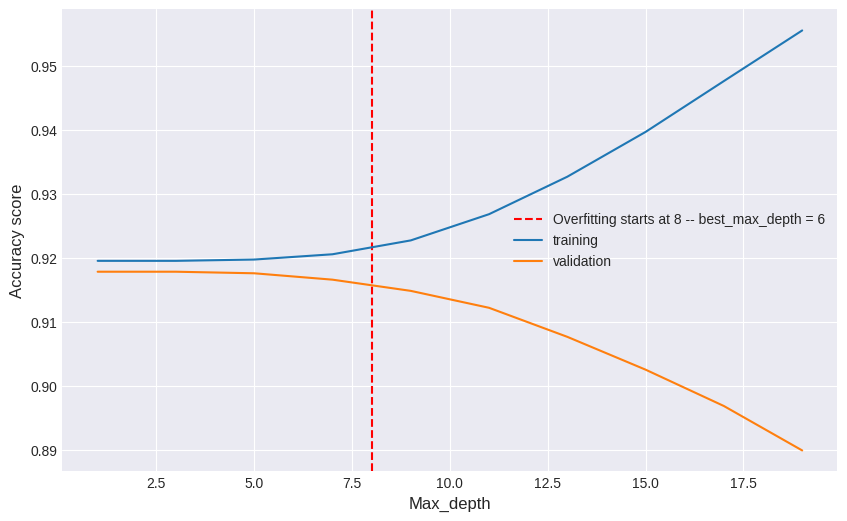

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(len(depth_hyperparams)):
    if training_acc[i]-validation_acc[i]>0.04:
        over_fit_depth=i
        best_max_depth=i-2

        plt.axvline(over_fit_depth ,color='red', linestyle='--',
                    label=f"Overfitting starts at {over_fit_depth} -- best_max_depth = {best_max_depth}"
                   )


        break
plt.plot(depth_hyperparams, training_acc, label = "training")
plt.plot(depth_hyperparams, validation_acc, label = "validation")


plt.xlabel("Max_depth")
plt.ylabel("Accuracy score")
plt.legend();

# Testing Data

In [74]:
test_path = path + "/application_test.csv"
df_TEST = pd.read_csv(test_path)

print("Original test shape:", df_TEST.shape)
display(df_TEST.head())

Original test shape: (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

*italicized text*### Preprocessing Test Data
Applying the `wrangle` and `full_missing_pipeline` functions to the test dataset with `is_test_data=True`.

In [75]:
# Make a copy to avoid modifying the original test DataFrame
df_test_processed = df_TEST.copy()

df_test_processed = wrangle(df_test_processed)
df_test_processed = full_missing_pipeline(df_test_processed, is_test_data=True)

print("Processed test shape:", df_test_processed.shape)
display(df_test_processed.head())

Numeric imputed: 56
Categorical imputed: 5
Remaining missing: 45280
Processed test shape: (48744, 104)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_DOCS_BIN,AGE,ID_PUBLISH_YEAR,REGISTRATION_YEAR,YEARS_EMPLOYED,YEARS_LAST_PHONE_CHANGE,IS_PENSIONER,INCOME_PER_PERSON,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EMPLOYMENT_RATIO,GOODS_CRIDET_RATIO,HOUSING_MEAN,HOUSING_STD
0,Cash loans,F,N,Y,0,11.813037,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,9.0,1,1,0,1,0,1,Missing,2.0,2,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,0.7552,0.00,0.1379,0.1250,0.2083,0.0483,0.0756,0.0505,0.0000,0.0038,0.0672,0.0612,0.9732,0.7583,0.0000,0.1379,0.1250,0.2083,0.0462,0.0817,0.0526,0.0000,0.0012,0.0666,0.0590,0.9732,0.7585,0.00,0.1379,0.1250,0.2083,0.0488,0.0770,0.0514,0.0000,0.0031,reg oper account,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,52.715068,-2.224658,-14.164384,6.380822,4.767123,0,5.906519,48150.190135,1740.492237,0.121044,0.791139,0.225316,0.334516
1,Cash loans,M,N,Y,0,11.502885,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,9.0,1,1,0,1,0,0,Low-skill Laborers,2.0,2,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,0.0928,0.0781,0.9816,0.7552,0.00,0.1379,0.1667,0.2083,0.0483,0.0756,0.0770,0.0000,0.0038,0.0851,0.0770,0.9816,0.7583,0.0000,0.1379,0.1667,0.2083,0.0462,0.0817,0.0751,0.0000,0.0012,0.0926,0.0778,0.9816,0.7585,0.00,0.1379,0.1667,0.2083,0.0488,0.0770,0.0776,0.0000,0.0031,reg oper account,block of flats,0.0707,Panel,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1,49.490411,-4.446575,-24.980822,12.243836,-0.000000,0,5.751443,19366.271639,1510.055925,0.247398,0.808016,NaN,NaN
2,Cash loans,M,Y,Y,0,12.218500,663264.0,69777.0,630000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.019101,5.0,1,1,0,1,0,0,Drivers,2.0,2,14,0,0,0,0,0,0,Transport: type 3,0.506771,0.699787,0.610991,0.0928,0.0781,0.9816,0.7552,0.00,0.1379,0.1667,0.2083,0.0483,0.0756,0.0770,0.0000,0.0038,0.0851,0.0770,0.9816,0.7583,0.0000,0.1379,0.1667,0.2083,0.0462,0.0817,0.0751,0.0000,0.0012,0.0926,0.0778,0.9816,0.7585,0.00,0.1379,0.1667,0.2083,0.0488,0.0770,0.0776,0.0000,0.0031,reg oper account,block of flats,0.0707,Panel,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1,54.898630,-9.597260,-5.958904,12.213699,2.345205,0,6.109250,54283.585904,5710.766412,0.222477,0.949848,NaN,NaN

### Aligning Columns
Ensuring the test set has the exact same columns as the training set, in the same order, for consistent feature sets before making predictions.

In [76]:
test_ids = df_TEST['SK_ID_CURR']

# Get columns from training data (used for CatBoost)
train_cols = X_train_cat.columns.tolist()

# Ensure the order of columns is the same as in the training set
df_test_aligned = df_test_processed[train_cols]

print("Aligned test shape:", df_test_aligned.shape)
display(df_test_aligned.head())

Aligned test shape: (48744, 103)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TOTAL_DOCS_BIN,AGE,ID_PUBLISH_YEAR,REGISTRATION_YEAR,YEARS_EMPLOYED,YEARS_LAST_PHONE_CHANGE,IS_PENSIONER,INCOME_PER_PERSON,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EMPLOYMENT_RATIO,GOODS_CRIDET_RATIO,HOUSING_MEAN,HOUSING_STD
0,Cash loans,F,N,Y,0,11.813037,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,1,1,0,1,0,1,Missing,2.0,2,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,0.7552,0.00,0.1379,0.1250,0.2083,0.0483,0.0756,0.0505,0.0000,0.0038,0.0672,0.0612,0.9732,0.7583,0.0000,0.1379,0.1250,0.2083,0.0462,0.0817,0.0526,0.0000,0.0012,0.0666,0.0590,0.9732,0.7585,0.00,0.1379,0.1250,0.2083,0.0488,0.0770,0.0514,0.0000,0.0031,reg oper account,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,52.715068,-2.224658,-14.164384,6.380822,4.767123,0,5.906519,48150.190135,1740.492237,0.121044,0.791139,0.225316,0.334516
1,Cash loans,M,N,Y,0,11.502885,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,1,1,0,1,0,0,Low-skill Laborers,2.0,2,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,0.0928,0.0781,0.9816,0.7552,0.00,0.1379,0.1667,0.2083,0.0483,0.0756,0.0770,0.0000,0.0038,0.0851,0.0770,0.9816,0.7583,0.0000,0.1379,0.1667,0.2083,0.0462,0.0817,0.0751,0.0000,0.0012,0.0926,0.0778,0.9816,0.7585,0.00,0.1379,0.1667,0.2083,0.0488,0.0770,0.0776,0.0000,0.0031,reg oper account,block of flats,0.0707,Panel,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1,49.490411,-4.446575,-24.980822,12.243836,-0.000000,0,5.751443,19366.271639,1510.055925,0.247398,0.808016,NaN,NaN
2,Cash loans,M,Y,Y,0,12.218500,663264.0,69777.0,630000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.019101,1,1,0,1,0,0,Drivers,2.0,2,14,0,0,0,0,0,0,Transport: type 3,0.506771,0.699787,0.610991,0.0928,0.0781,0.9816,0.7552,0.00,0.1379,0.1667,0.2083,0.0483,0.0756,0.0770,0.0000,0.0038,0.0851,0.0770,0.9816,0.7583,0.0000,0.1379,0.1667,0.2083,0.0462,0.0817,0.0751,0.0000,0.0012,0.0926,0.0778,0.9816,0.7585,0.00,0.1379,0.1667,0.2083,0.0488,0.0770,0.0776,0.0000,0.0031,reg oper account,block of flats,0.0707,Panel,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1,54.898630,-9.597260,-5.958904,12.213699,2.345205,0,6.109250,54283.585904,5710.766412,0.222477,0.949848,NaN,NaN
3,Cash loans,F,N,Y,2,12

### Making Predictions and Creating Submission File
Using the trained `cat_model` to predict probabilities on the aligned test data and creating the `submission.csv` file.

In [77]:
test_predictions = cat_model.predict_proba(df_test_aligned)[:, 1]

submission = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET': test_predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
display(submission.head())

Submission file created successfully!


,SK_ID_CURR,TARGET
0,100001,0.051552
1,100005,0.125889
2,100013,0.020368
3,100028,0.028735
4,100038,0.113902


In [86]:
len(submission[submission["TARGET"] > 0.5]["TARGET"]) / len(submission) *100

0.14155588380108322

In [78]:
# Download Model
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
# save catboost model
import pickle
pickle.dump(cat_model, open('cat_model.pkl', 'wb'))



In [ ]:
# to use model after upload it
model = pickle.load(open('cat_model.pkl', 'rb'))
df_test = pd.read_csv('application_test.csv')
df_test = wrangle(df_test)
df_test = full_missing_pipeline(df_test, is_test_data=True)

# applu model on df_test
test_predictions = model.predict_proba(df_test)[:, 1]




In [90]:
df_TEST.to_csv("df_TEST.csv", index=False)
